In [1]:
# W3D5: Hyperparameter Tuning — GridSearch & RandomSearch

import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Load the Breast Cancer dataset

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset Shape:", X.shape)
print("\nTarget Classes:", data.target_names)

display(X.head())

Dataset Shape: (569, 30)

Target Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [4]:
# Scaling + SVM pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

print("Pipeline created successfully.")

Pipeline created successfully.


In [5]:
# Define parameters for exhaustive grid search

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best GridSearch Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_, 4))

Best GridSearch Parameters:
{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

Best Cross-Validation Accuracy:
0.978


In [6]:
grid_pred = grid_search.predict(X_test)

grid_accuracy = accuracy_score(
    y_test,
    grid_pred
)

print("GridSearch Test Accuracy:", round(grid_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        grid_pred,
        target_names=data.target_names
    )
)

GridSearch Test Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [7]:
# Define parameter distributions for randomized search

param_distributions = {
    "svm__C": np.logspace(-2, 2, 20),
    "svm__kernel": ["linear", "rbf", "poly", "sigmoid"],
    "svm__gamma": ["scale", "auto"]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best RandomSearch Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(random_search.best_score_, 4))

Best RandomSearch Parameters:
{'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__C': np.float64(5.455594781168514)}

Best Cross-Validation Accuracy:
0.9758


In [8]:
random_pred = random_search.predict(X_test)

random_accuracy = accuracy_score(
    y_test,
    random_pred
)

print("RandomSearch Test Accuracy:", round(random_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        random_pred,
        target_names=data.target_names
    )
)

RandomSearch Test Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [9]:
results = pd.DataFrame({
    "Method": [
        "GridSearchCV",
        "RandomizedSearchCV"
    ],
    "CV Accuracy": [
        grid_search.best_score_,
        random_search.best_score_
    ],
    "Test Accuracy": [
        grid_accuracy,
        random_accuracy
    ]
})

display(results)

,Method,CV Accuracy,Test Accuracy
0,GridSearchCV,0.978022,0.982456
1,RandomizedSearchCV,0.975824,0.982456


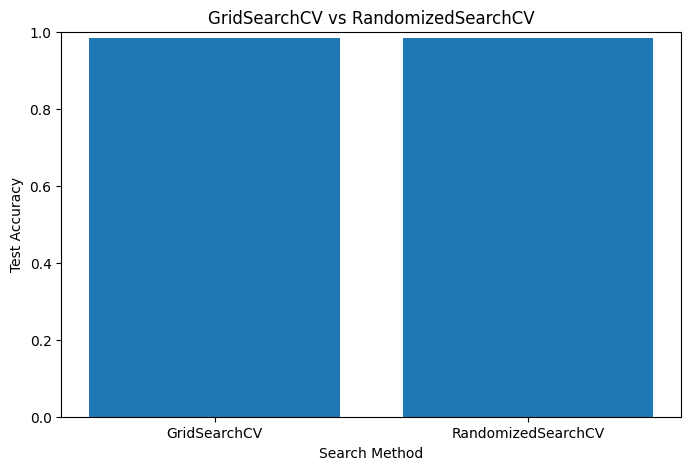

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results["Method"],
    results["Test Accuracy"]
)

plt.title("GridSearchCV vs RandomizedSearchCV")
plt.xlabel("Search Method")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.show()

In [11]:
if grid_accuracy >= random_accuracy:
    best_model = grid_search.best_estimator_
    best_method = "GridSearchCV"
    best_accuracy = grid_accuracy
else:
    best_model = random_search.best_estimator_
    best_method = "RandomizedSearchCV"
    best_accuracy = random_accuracy

print("Best Method:", best_method)
print("Best Test Accuracy:", round(best_accuracy, 4))

Best Method: GridSearchCV
Best Test Accuracy: 0.9825


In [12]:
results.to_csv(
    "W3D5_Hyperparameter_Tuning_Results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
